In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import math

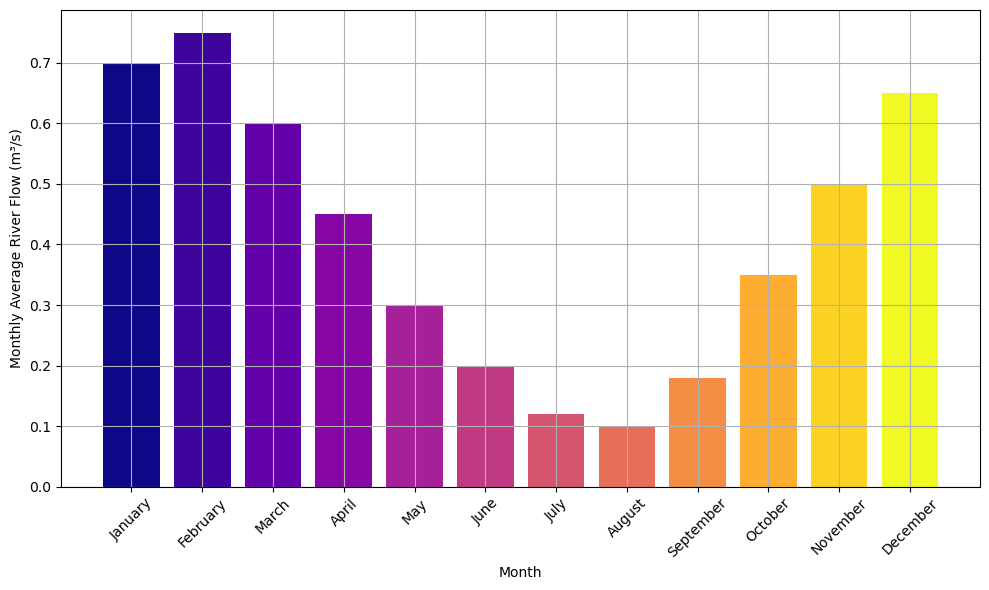

In [2]:
## From the project statement
H_b = 200 # m , La Palma Gross Head
Q_river = [0.70, 0.75, 0.60, 0.45, 0.30, 0.20, 0.12, 0.10, 0.18, 0.35, 0.50, 0.65] # m^3/s , Average Flow for each month
month_names = ["January", "February", "March", "April","May", "June", "July", "August","September", "October", "November", "December"]
months = range(1, 13)
cmap = plt.colormaps["plasma"]

plt.figure(figsize=(10, 6))
plt.bar( months, Q_river, color=[cmap((month - 1) / 11) for month in months])
plt.xlabel("Month")
plt.ylabel("Monthly Average River Flow (m³/s)")
plt.xticks( range(1, 13), month_names, rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

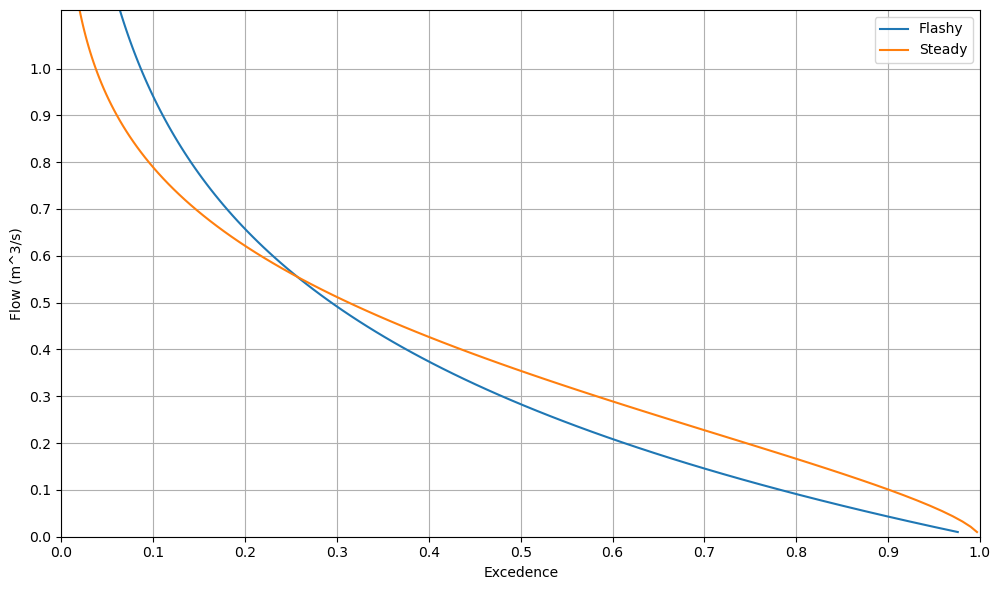

In [3]:

## Construct FDC (Flow duration curve) # Bridging Monthly Data to Continuous FDC
Q_avg = np.mean(Q_river) # Calculate Q_avg: Compute the annual mean from the 12 monthly flow values
k_flashy = 1 #Assume k: Select a shape parameter (k) reflecting the island’s terrain and expected river volatility.
k_steady = 1.5
c_flashy = Q_avg/math.gamma(1+1/k_flashy) # Solve for c: Rearrange the Mean Flow Relation to find the scale parameter: c = Q_avg/Γ(1 + 1/k).
c_steady = Q_avg/math.gamma(1+1/k_steady)

# Generate Curve: Plot a range of flows (q) against their Exceedance Probability E(Q ≥ q)
Q = np.linspace(0.01, max(Q_river)*1.5, 100)
E_flashy = np.exp(-(Q/c_flashy)**k_flashy)
E_steady = np.exp(-(Q/c_steady)**k_steady)



plt.figure(figsize=(10, 6))
plt.plot(E_flashy , Q , label="Flashy")
plt.plot(E_steady , Q , label="Steady")
#plt.plot([0.25,0.25],[0.5,0.6] , marker="o")
#plt.plot([0.2,0.3],[0.5,0.5] , marker="o")

plt.xlabel("Excedence")
plt.ylabel("Flow (m^3/s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.xlim(0, 1)
plt.xticks(np.linspace(0, 1, 11))
plt.ylim(0,  max(Q_river)*1.5)
plt.yticks(np.linspace(0, 1, 11))
plt.show()

In [ ]:
from scipy.optimize import brentq

def E_flashy_func(Q):
    return np.exp(-(Q / c_flashy)**k_flashy)

def E_steady_func(Q):
    return np.exp(-(Q / c_steady)**k_steady)

def difference(Q):
    return E_flashy_func(Q) - E_steady_func(Q)

# Find the non-zero intersection
Q_intersect = brentq( difference, 0.001, max(Q_river) * 10)# Corresponding exceedance
E_intersect = E_flashy_func(Q_intersect)

print(f"Intersection flow = {Q_intersect:.4f} m³/s")
print(f"Exceedance = {E_intersect:.4f}")

Intersection flow = 0.5550 m³/s
Exceedance = 0.2568


In [ ]:
Q_d = Q_intersect # m^3/s
Q_river = np.array(Q_river)
Q_turbine = np.minimum(Q_d , Q_river*(1-0.15)) # Deduct exactly 15% of the streamflow as mandatory environmental flow
H_net = H_b * ( 1 - 0.08* (Q_turbine/Q_d)**2)
H_net_design = H_b * ( 1 - 0.08* (Q_d/Q_d)**2)

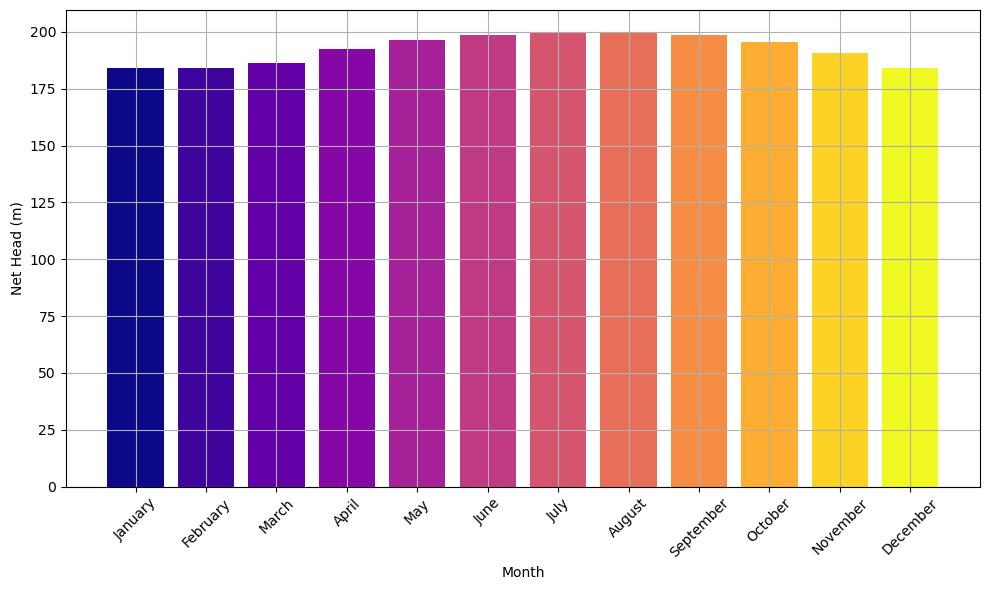

In [26]:
plt.figure(figsize=(10, 6))
plt.bar( months, H_net, color=[cmap((month - 1) / 11) for month in months])
#plt.ylim(0,200)
plt.xlabel("Month")
plt.ylabel("Net Head (m)")
plt.xticks( range(1, 13), month_names, rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

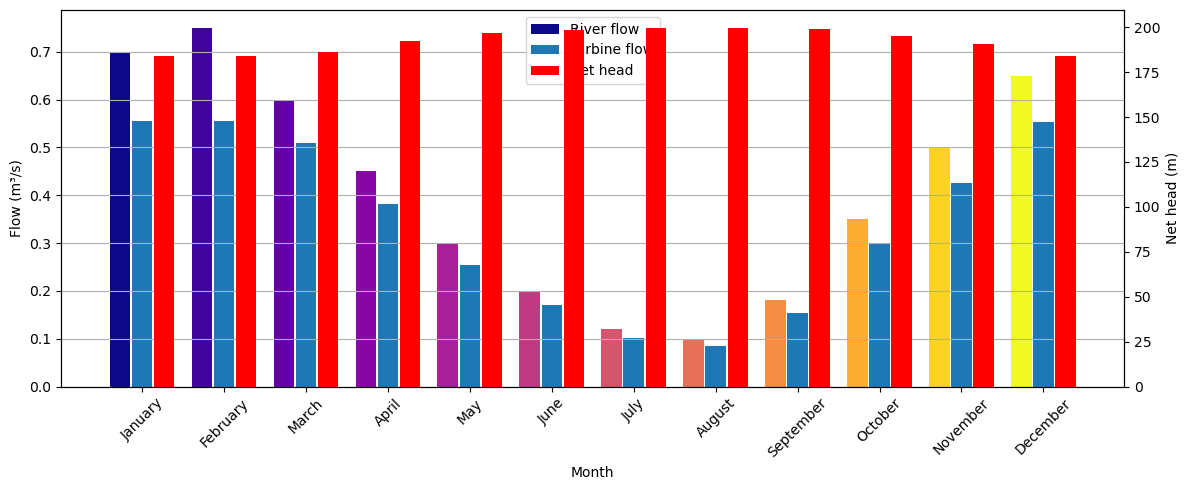

In [32]:
# Bar width and offsets
width = 0.25

fig, ax1 = plt.subplots(figsize=(12, 5))

months = np.arange(1, 13)

# Flow bars
ax1.bar( months - width-0.02, Q_river, width, label="River flow", color=[cmap((month - 1) / 11) for month in months])
ax1.bar(months,Q_turbine,width,label="Turbine flow")
ax1.set_xlabel("Month")
ax1.set_ylabel("Flow (m³/s)")
ax1.set_xticks(months)
ax1.set_xticklabels(month_names, rotation=45)
ax1.grid(axis="y")

# Second y-axis for head
ax2 = ax1.twinx()
ax2.bar( months + width+0.02, H_net, width, label="Net head",color="red")
ax2.set_ylabel("Net head (m)")

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend( handles1 + handles2, labels1 + labels2 , loc="best" ) #
plt.tight_layout()
plt.show()